# MNIST Digit Classification — ANN from Scratch
**Dataset:** MNIST (70,000 handwritten digits)  
**Framework:** TensorFlow / Keras  
**Model:** Pure ANN  
**Task:** 10-class multiclass classification (digits 0–9)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

print('TF version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

2026-06-13 11:49:29.488460: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781351369.920305      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781351370.039053      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781351371.054158      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781351371.054229      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781351371.054232      58 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU available: []


2026-06-13 11:49:50.359420: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

print('Full train shape:', X_train_full.shape)  # (60000, 28, 28)
print('Test shape:      ', X_test.shape)         # (10000, 28, 28)
print('Pixel range:     ', X_train_full.min(), '-', X_train_full.max())
print('Classes:         ', np.unique(y_train_full))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Full train shape: (60000, 28, 28)
Test shape:       (10000, 28, 28)
Pixel range:      0 - 255
Classes:          [0 1 2 3 4 5 6 7 8 9]


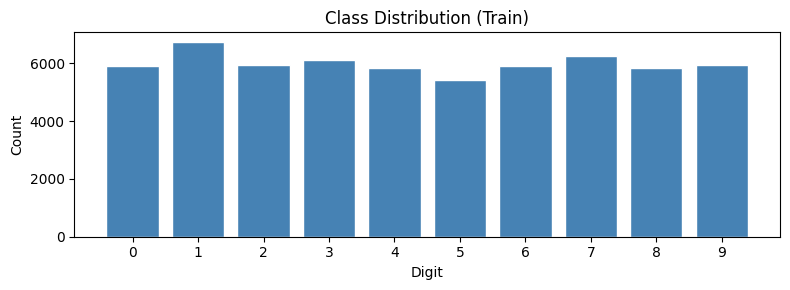

In [3]:
# Class distribution
plt.figure(figsize=(8, 3))
unique, counts = np.unique(y_train_full, return_counts=True)
plt.bar(unique, counts, color='steelblue', edgecolor='white')
plt.xticks(unique)
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Class Distribution (Train)')
plt.tight_layout()
plt.show()

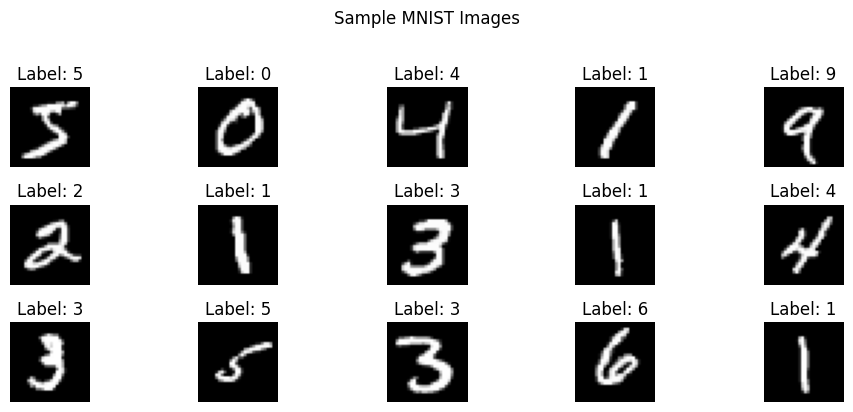

In [4]:
# Visualise sample images
plt.figure(figsize=(10, 4))
for i in range(15):
    ax = plt.subplot(3, 5, i + 1)
    plt.imshow(X_train_full[i], cmap='gray')
    plt.title(f'Label: {y_train_full[i]}')
    plt.axis('off')
plt.suptitle('Sample MNIST Images', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# Normalise to [0, 1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32') / 255.0

# Flatten 28x28 -> 784 (ANN takes 1D input, not 2D)
X_train_full = X_train_full.reshape(-1, 784)
X_test       = X_test.reshape(-1, 784)

# Train / Val split from the 60K training set (85/15)
val_size = int(0.15 * len(X_train_full))
X_val,   y_val   = X_train_full[:val_size],  y_train_full[:val_size]
X_train, y_train = X_train_full[val_size:],  y_train_full[val_size:]

print('Train:', X_train.shape)
print('Val:  ', X_val.shape)
print('Test: ', X_test.shape)

Train: (51000, 784)
Val:   (9000, 784)
Test:  (10000, 784)


In [6]:
def build_ann(input_dim=784, num_classes=10):
    inputs = keras.Input(shape=(input_dim,), name='input')

    # Hidden layer 1
    x = layers.Dense(512, activation='relu', name='dense_1')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Hidden layer 2
    x = layers.Dense(256, activation='relu', name='dense_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Hidden layer 3
    x = layers.Dense(128, activation='relu', name='dense_3')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # Output: 10 classes with softmax
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return keras.Model(inputs, outputs, name='MNIST_ANN')

model = build_ann()
model.summary()

Model: "MNIST_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_ann.keras', monitor='val_accuracy', save_best_only=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=callbacks
)

Epoch 1/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9048 - loss: 0.3106 - val_accuracy: 0.9557 - val_loss: 0.1395 - learning_rate: 0.0010
Epoch 2/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9542 - loss: 0.1491 - val_accuracy: 0.9674 - val_loss: 0.1079 - learning_rate: 0.0010
Epoch 3/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9646 - loss: 0.1139 - val_accuracy: 0.9732 - val_loss: 0.0889 - learning_rate: 0.0010
Epoch 4/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9692 - loss: 0.0958 - val_accuracy: 0.9750 - val_loss: 0.0836 - learning_rate: 0.0010
Epoch 5/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9738 - loss: 0.0810 - val_accuracy: 0.9784 - val_loss: 0.0803 - learning_rate: 0.0010
Epoch 6/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9763 - loss: 0.0740 - val_accuracy: 0.9761 - val_loss: 0.0851 - learning_rate: 0.0010
Epoch 7/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9787 - loss: 0.

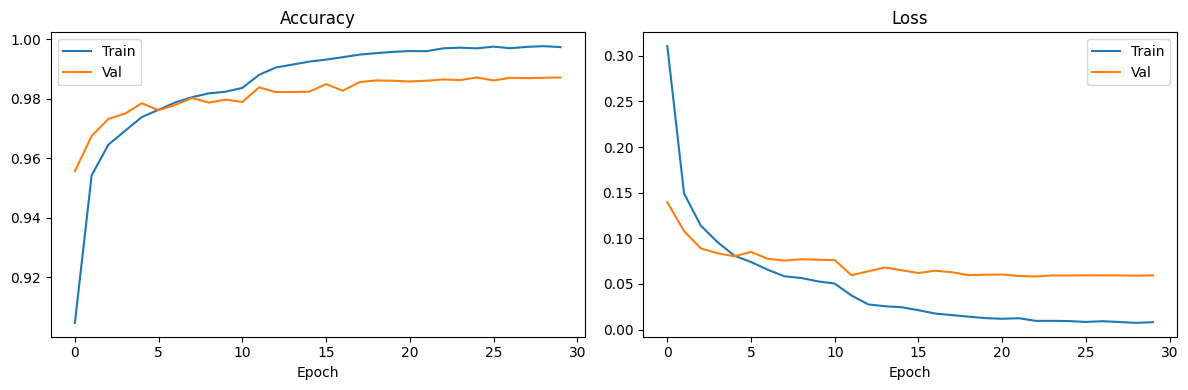

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f'\nTest accuracy: {test_acc:.4f}')
print(f'Test loss:     {test_loss:.4f}')

y_pred = np.argmax(model.predict(X_test), axis=1)

print('\n', classification_report(y_test, y_pred, digits=4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9849 - loss: 0.0564

Test accuracy: 0.9849
Test loss:     0.0564
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

               precision    recall  f1-score   support

           0     0.9858    0.9929    0.9893       980
           1     0.9912    0.9938    0.9925      1135
           2     0.9807    0.9826    0.9816      1032
           3     0.9832    0.9871    0.9852      1010
           4     0.9846    0.9796    0.9821       982
           5     0.9854    0.9843    0.9849       892
           6     0.9895    0.9843    0.9869       958
           7     0.9825    0.9835    0.9830      1028
           8     0.9836    0.9825    0.9831       974
           9     0.9821    0.9772    0.9796      1009

    accuracy                         0.9849     10000
   macro avg     0.9849    0.9848    0.9848     10000
weighted avg     0.9849    0.9849    0.9849     10000



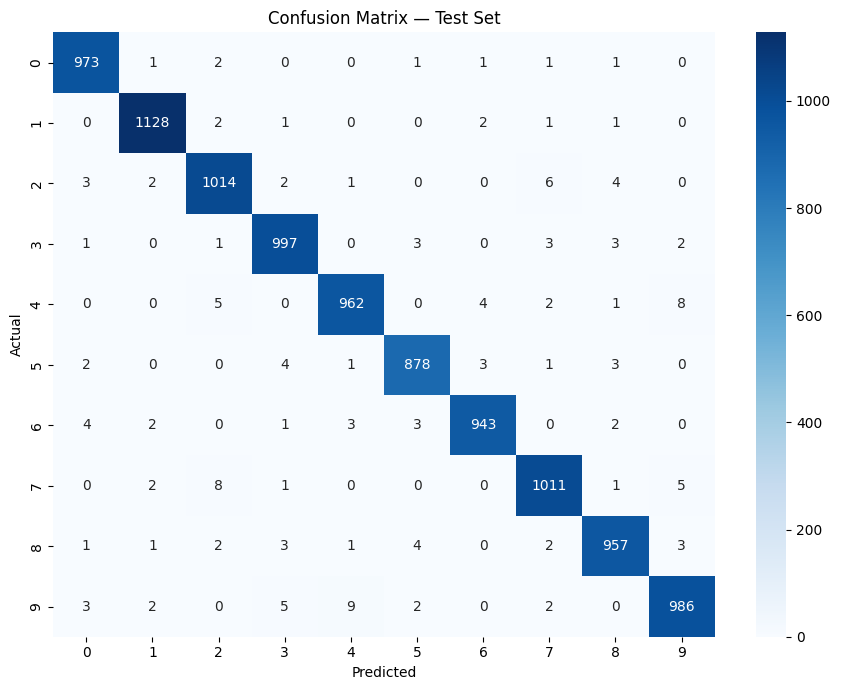

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix — Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Total misclassified: 151 / 10000


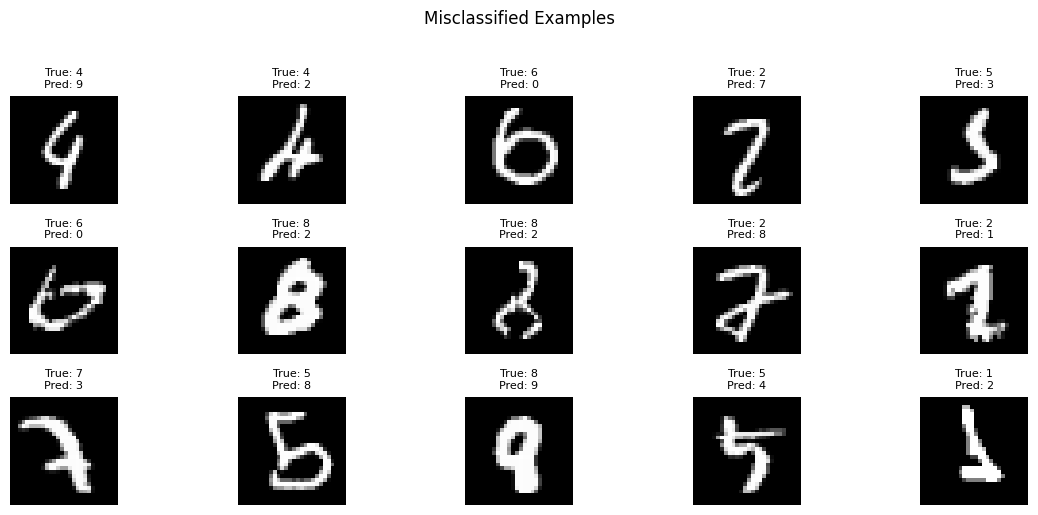

In [11]:
misclassified_idx = np.where(y_pred != y_test)[0]
print(f'Total misclassified: {len(misclassified_idx)} / {len(y_test)}')

plt.figure(figsize=(12, 5))
for i, idx in enumerate(misclassified_idx[:15]):
    ax = plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f'True: {y_test[idx]}\nPred: {y_pred[idx]}', fontsize=8)
    plt.axis('off')
plt.suptitle('Misclassified Examples', y=1.02)
plt.tight_layout()
plt.show()

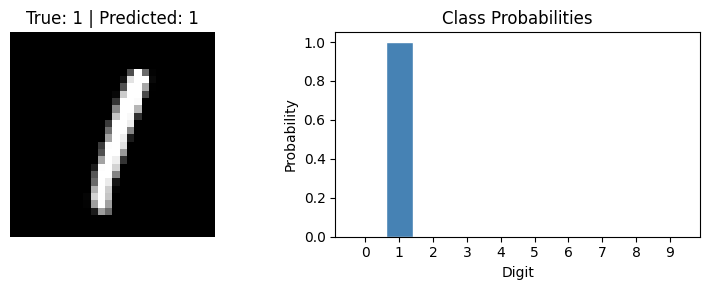

In [15]:
def predict_single(idx, model, X, y):
    img   = X[idx].reshape(1, 784)
    probs = model.predict(img, verbose=0)[0]
    pred  = np.argmax(probs)

    plt.figure(figsize=(8, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(X[idx].reshape(28, 28), cmap='gray')
    plt.title(f'True: {y[idx]} | Predicted: {pred}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.bar(range(10), probs, color='steelblue', edgecolor='white')
    plt.xticks(range(10))
    plt.xlabel('Digit')
    plt.ylabel('Probability')
    plt.title('Class Probabilities')

    plt.tight_layout()
    plt.show()

# Try any index
predict_single(5, model, X_test, y_test)